# Laboratorio 4 (Parte 2) — Inciso 6: Validación espacial y temporal

Se divide cada lago en una cuadrícula regular de aproximadamente 1 km x 1 km sobre las coordenadas UTM 15N (EPSG:32615, ya calculadas en el inciso 1), se evalúa si ese tamaño produce bloques suficientes, se visualizan los bloques, y se compara el desempeño de los tres modelos bajo tres estrategias de validación cruzada: aleatoria, espacial (agrupada por bloque) y temporal (agrupada por fecha de adquisición).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import LAGOS, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.espacial import (
    TAMANO_BLOQUE_M,
    asignar_bloques,
    asignar_grupos_temporales,
    cv_aleatoria,
    cv_espacial,
    cv_temporal,
    n_splits_seguro,
    resumen_bloques,
    resumen_grupos_temporales,
)
from src.modelado import PREDICTORES, agregar_features, construir_modelos_base, construir_respuesta

colores = {"atitlan": "teal", "amatitlan": "darkorange"}

muestra = pd.read_parquet(RUTA_DATA_PROCESSED / "dataset_ml_muestra.parquet")
muestra = construir_respuesta(agregar_features(muestra))
print(f"{len(muestra):,} observaciones en la muestra de trabajo")

299,992 observaciones en la muestra de trabajo


## 6.1 Cuadrícula de bloques y evaluación del tamaño

Las coordenadas `x_utm`/`y_utm` (EPSG:32615, metros) ya se calcularon en el inciso 1 al construir el dataset, por lo que no se requiere una reproyección adicional en este inciso; se reutilizan directamente para construir la cuadrícula.

In [2]:
bloques = asignar_bloques(muestra, tam_m=TAMANO_BLOQUE_M)
resumen = resumen_bloques(muestra, bloques)
resumen.to_csv(RUTA_DATA_PROCESSED / "p2_resumen_bloques.csv")
resumen

,n_bloques,obs_por_bloque_min,obs_por_bloque_mediana,obs_por_bloque_max
lago,,,,
amatitlan,38,42,3128.0,10859
atitlan,165,2,1181.0,1344


*(Completar tras ejecutar: si `n_bloques` es bajo -por ejemplo, decenas en lugar de cientos- para alguno de los lagos, especialmente Amatitlán por su menor extensión, se debe justificar aquí si 1 km sigue siendo un tamaño adecuado o si conviene un tamaño menor. `n_splits_seguro`, a continuación, ya adapta automáticamente el número de folds al lago con menos bloques y a la clase minoritaria, para que la validación espacial no falle por falta de grupos.)*

In [3]:
n_splits = n_splits_seguro(bloques, muestra["alta_cianobacteria"], maximo=5)
print(f"Bloques totales: {bloques.nunique():,}")
print(f"Folds usados en la validación cruzada (aleatoria, espacial y temporal): {n_splits}")

Bloques totales: 203
Folds usados en la validación cruzada (aleatoria, espacial y temporal): 5


## 6.2 Mapa de bloques

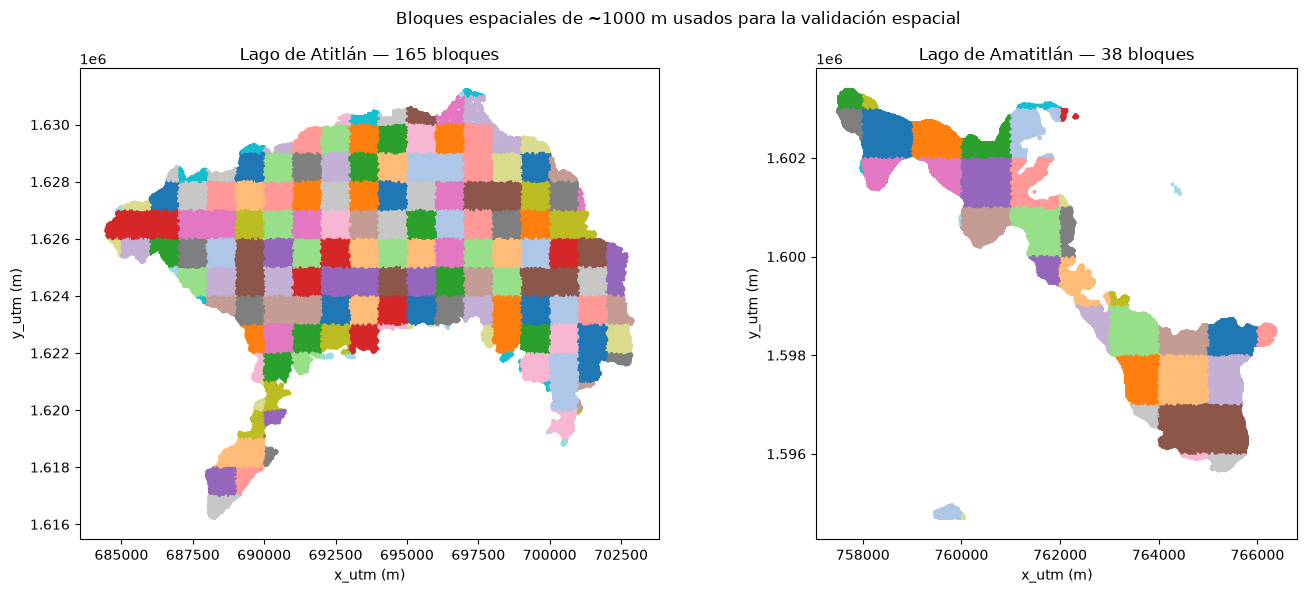

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lago in zip(axes, LAGOS):
    sub = muestra[muestra["lago"] == lago]
    bloques_lago = bloques[muestra["lago"] == lago]
    codigos = pd.factorize(bloques_lago)[0]
    ax.scatter(sub["x_utm"], sub["y_utm"], c=codigos, cmap="tab20", s=2)
    ax.set_title(f"{LAGOS[lago]['nombre']} — {bloques_lago.nunique()} bloques")
    ax.set_xlabel("x_utm (m)")
    ax.set_ylabel("y_utm (m)")
    ax.set_aspect("equal")
fig.suptitle(f"Bloques espaciales de ~{TAMANO_BLOQUE_M} m usados para la validación espacial")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_bloques_espaciales.png", dpi=150)
plt.show()

## 6.3 y 6.4 Validación cruzada espacial, temporal y aleatoria

Se entrena de nuevo cada uno de los tres modelos (con los mismos hiperparámetros por defecto usados como punto de partida en el inciso 4.1) bajo tres estrategias de validación cruzada:

- **aleatoria** estratificada (`cv_aleatoria`), la línea base equivalente a la división del inciso 4;
- **espacial** agrupada por bloque de ~1 km (`cv_espacial`), mediante `StratifiedGroupKFold`, que impide que observaciones del mismo bloque queden repartidas entre entrenamiento y validación dentro de un mismo fold;
- **temporal** agrupada por fecha de adquisición (`cv_temporal`), con la misma mecánica de grupos pero usando la escena completa como grupo, de modo que cada fold se evalúa sobre fechas que el modelo no vio durante su entrenamiento.

In [5]:
X = muestra[PREDICTORES]
y = muestra["alta_cianobacteria"]

grupos_temporales = asignar_grupos_temporales(muestra)
resumen_temporal = resumen_grupos_temporales(muestra, grupos_temporales)
resumen_temporal.to_csv(RUTA_DATA_PROCESSED / "p2_resumen_grupos_temporales.csv")
print(f"Fechas distintas usadas como grupo temporal: {grupos_temporales.nunique()}")
resumen_temporal

Fechas distintas usadas como grupo temporal: 20


,n_fechas,obs_por_fecha_min,obs_por_fecha_mediana,obs_por_fecha_max
lago,,,,
amatitlan,11,13636,13636.0,13636
atitlan,11,13636,13636.0,13636


In [6]:
resultados_cv = []
for nombre, modelo in construir_modelos_base().items():
    res_aleatoria = cv_aleatoria(modelo, X, y, n_splits=n_splits)
    res_espacial = cv_espacial(modelo, X, y, bloques, n_splits=n_splits)
    res_temporal = cv_temporal(modelo, X, y, grupos_temporales, n_splits=n_splits)
    for estrategia, res in [("aleatoria", res_aleatoria), ("espacial", res_espacial), ("temporal", res_temporal)]:
        resultados_cv.append({
            "modelo": nombre,
            "estrategia": estrategia,
            "roc_auc_medio": np.mean(res["test_roc_auc"]),
            "roc_auc_std": np.std(res["test_roc_auc"]),
            "recall_medio": np.mean(res["test_recall"]),
            "f1_medio": np.mean(res["test_f1"]),
        })

tabla_cv = pd.DataFrame(resultados_cv)
tabla_cv.to_csv(RUTA_DATA_PROCESSED / "p2_cv_aleatoria_vs_espacial.csv", index=False)
tabla_cv.round(4)

,modelo,estrategia,roc_auc_medio,roc_auc_std,recall_medio,f1_medio
0,regresion_logistica,aleatoria,0.9989,0.0001,0.9932,0.8711
1,regresion_logistica,espacial,0.9987,0.0007,0.9927,0.8713
2,regresion_logistica,temporal,0.9977,0.0019,0.9758,0.7633
3,random_forest,aleatoria,0.9993,0.0002,0.9700,0.9465
4,random_forest,espacial,0.9991,0.0006,0.9604,0.9400
5,random_forest,temporal,0.9968,0.0023,0.6839,0.7428
6,gradient_boosting,aleatoria,0.9992,0.0001,0.9391,0.9410
7,gradient_boosting,espacial,0.9991,0.0005,0.9304,0.9347
8,gradient_boosting,temporal,0.9973,0.0028,0.8045,0.8414


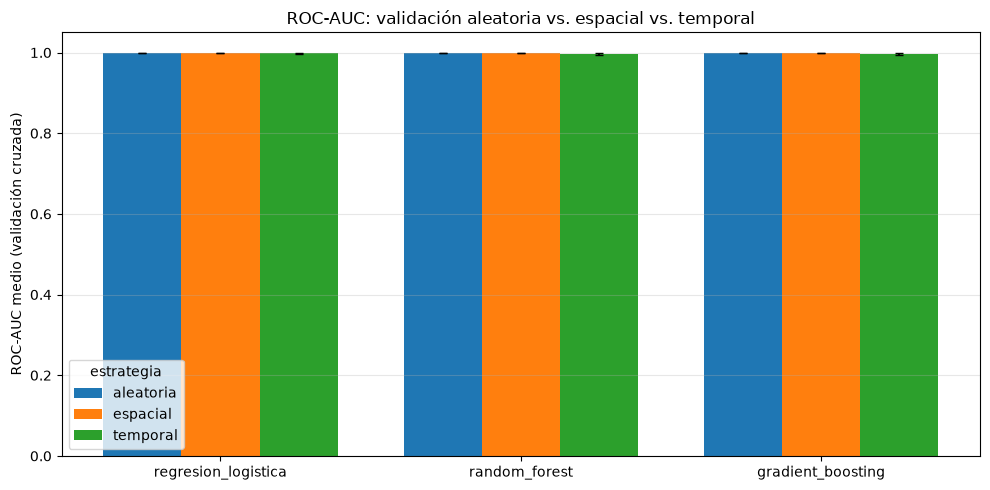

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
estrategias = ["aleatoria", "espacial", "temporal"]
ancho = 0.26
modelos_orden = tabla_cv["modelo"].unique()
x = np.arange(len(modelos_orden))
for i, estrategia in enumerate(estrategias):
    valores = [tabla_cv[(tabla_cv["modelo"] == m) & (tabla_cv["estrategia"] == estrategia)]["roc_auc_medio"].iloc[0] for m in modelos_orden]
    errores = [tabla_cv[(tabla_cv["modelo"] == m) & (tabla_cv["estrategia"] == estrategia)]["roc_auc_std"].iloc[0] for m in modelos_orden]
    ax.bar(x + i * ancho, valores, width=ancho, yerr=errores, capsize=3, label=estrategia)
ax.set_xticks(x + ancho)
ax.set_xticklabels(modelos_orden)
ax.set_ylabel("ROC-AUC medio (validación cruzada)")
ax.set_title("ROC-AUC: validación aleatoria vs. espacial vs. temporal")
ax.legend(title="estrategia")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_comparacion_cv.png", dpi=150)
plt.show()

## 6.5 y 6.6 Comparación e interpretación

*(Completar tras ejecutar: comparar, para cada modelo, `roc_auc_medio` entre las estrategias "aleatoria" y "espacial" en `tabla_cv`, y reportar la magnitud de la diferencia.)*

Se espera que el ROC-AUC bajo validación espacial sea **menor** que bajo validación aleatoria, en mayor o menor grado según el modelo. La razón es la autocorrelación espacial: en la validación aleatoria, píxeles vecinos del mismo evento de floración (misma fecha, mismo parche de agua) pueden repartirse entre entrenamiento y prueba, de modo que el modelo "ve" durante el entrenamiento condiciones casi idénticas a las que luego evalúa, inflando el desempeño reportado. La validación espacial, al mantener cada bloque completo dentro de un único conjunto, obliga al modelo a predecir sobre zonas que nunca observó durante el entrenamiento, lo que da una estimación más realista de su capacidad para generalizar a zonas nuevas del mismo lago — el escenario relevante para el inciso 9 (mapas predictivos) y para un uso operativo real del modelo.

### Self-check

In [8]:
assert bloques.nunique() > 0
assert (resumen["n_bloques"] > 0).all()
assert 2 <= n_splits <= 5
assert grupos_temporales.nunique() >= n_splits
assert set(tabla_cv["estrategia"]) == {"aleatoria", "espacial", "temporal"}
assert set(tabla_cv["modelo"]) == {"regresion_logistica", "random_forest", "gradient_boosting"}
assert tabla_cv["roc_auc_medio"].between(0, 1).all()
print("OK: bloques espaciales y grupos temporales construidos; validación cruzada aleatoria/espacial/temporal ejecutada para los 3 modelos.")

OK: bloques espaciales y grupos temporales construidos; validación cruzada aleatoria/espacial/temporal ejecutada para los 3 modelos.
